### Import and configure modules

In [12]:
import os
import tensorflow as tf

import IPython.display as display

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (12, 12)
mpl.rcParams['axes.grid'] = False

import numpy as np
import PIL.Image
import time
import functools

In [13]:
# content_path = tf.keras.utils.get_file('dog.jpg', 'url')
# style_path = tf.keras.utils.get_file('starry_night_full.jpg','https://url')
content_path = 'img/dog.jpg'
style_path = 'img/starry_night_full.jpg'

### Image Loading and Display

In [14]:
# Utility function to load and preprocess an image from the given file path.
# The image is resized so that its largest dimension is 512 pixels,
# normalized to float32 [0,1], and batch dimension is added.
def load_img(path_to_img):
  max_dim = 512
  img = tf.io.read_file(path_to_img)
  img = tf.image.decode_image(img, channels=3)
  img = tf.image.convert_image_dtype(img, tf.float32)

  shape = tf.cast(tf.shape(img)[:-1], tf.float32)
  long_dim = max(shape)
  scale = max_dim / long_dim

  new_shape = tf.cast(shape * scale, tf.int32)

  img = tf.image.resize(img, new_shape)
  img = img[tf.newaxis, :]
  return img


# Utility function to display an image using matplotlib.
# If the image has a batch dimension, it is removed before displaying.
def imshow(image, title=None):
  if len(image.shape) > 3:
    image = tf.squeeze(image, axis=0)

  plt.imshow(image)
  if title:
    plt.title(title)


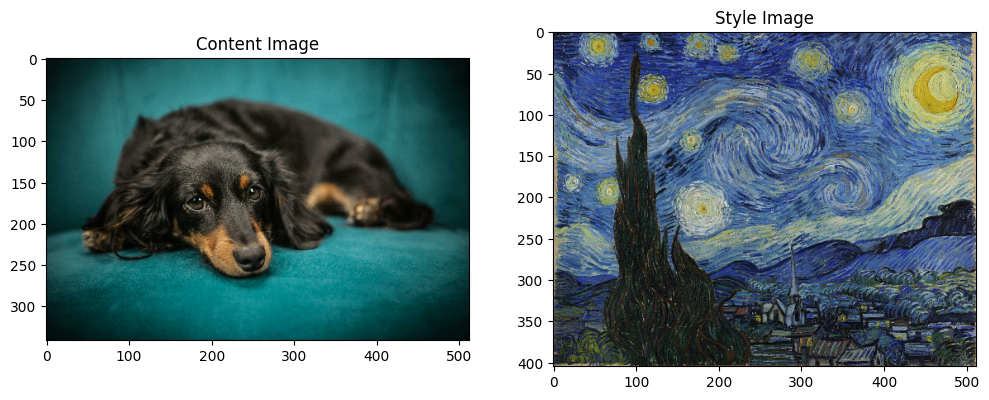

In [4]:
# Load and preprocess the content and style images.
# Then display them side by side for comparison.
content_image = load_img(content_path)
style_image = load_img(style_path)

plt.subplot(1, 2, 1)
imshow(content_image, 'Content Image')

plt.subplot(1, 2, 2)
imshow(style_image, 'Style Image')

### Feature Extraction for Style and Content Representation

This section sets up the VGG19 model and defines the layers used to extract content and style features from an image. It also includes the gram_matrix function to compute style representations via feature correlations.

In [5]:
# Load the pre-trained VGG19 model from Keras without the top classification layers.
vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')

# Choose intermediate layers from the network to represent the style and content of the image:
content_layers = ['block5_conv2']

style_layers = ['block1_conv1',
                'block2_conv1',
                'block3_conv1',
                'block4_conv1',
                'block5_conv1']

num_content_layers = len(content_layers)
num_style_layers = len(style_layers)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [6]:
def vgg_layers(layer_names):

  """Creates a VGG19 model that returns intermediate layer outputs.

  Args:
    layer_names: List of layer names whose outputs will be extracted.

  Returns:
    A Keras model that takes an image input and outputs the specified layers.
  """

  # Load the model. Load pretrained VGG, trained on ImageNet data
  vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
  vgg.trainable = False

  outputs = [vgg.get_layer(name).output for name in layer_names]

  model = tf.keras.Model([vgg.input], outputs)
  return model


# Create a model that extracts style features from the specified layers
style_extractor = vgg_layers(style_layers)

# Pass the style image (scaled back to [0, 255]) through the model
# to obtain the intermediate layer outputs
style_outputs = style_extractor(style_image*255)

# Print out basic statistics for each layer's output
for name, output in zip(style_layers, style_outputs):
  print(name)
  print("  shape: ", output.numpy().shape)
  print("  min: ", output.numpy().min())
  print("  max: ", output.numpy().max())
  print("  mean: ", output.numpy().mean())
  print()


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_22']
Received: inputs=Tensor(shape=(1, 405, 512, 3))
  warnings.warn(msg)


block1_conv1
  shape:  (1, 405, 512, 64)
  min:  0.0
  max:  673.43005
  mean:  23.779352

block2_conv1
  shape:  (1, 202, 256, 128)
  min:  0.0
  max:  2831.3438
  mean:  146.8449

block3_conv1
  shape:  (1, 101, 128, 256)
  min:  0.0
  max:  7256.615
  mean:  141.31274

block4_conv1
  shape:  (1, 50, 64, 512)
  min:  0.0
  max:  16345.258
  mean:  554.7913

block5_conv1
  shape:  (1, 25, 32, 512)
  min:  0.0
  max:  3919.4275
  mean:  47.456856



In [7]:
def gram_matrix(input_tensor):

  """Computes the Gram matrix for an input tensor.

  The Gram matrix captures the correlations between the filters (channels),
  and is commonly used in style transfer to represent the style of an image.

  Args:
    input_tensor: A 4D tensor of shape (batch_size, height, width, channels)

  Returns:
    A 3D tensor of shape (batch_size, channels, channels) representing
    the normalized Gram matrix for each image in the batch.
  """
  result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
  input_shape = tf.shape(input_tensor)
  num_locations = tf.cast(input_shape[1]*input_shape[2], tf.float32)
  return result/(num_locations)

#### Creat a model that returns style and content features from intermediate VGG19 layers.

This custom model is used in neural style transfer to extract features for computing content and style losses. It processes the input image through a frozen VGG19 network and separates the outputs into style and content representations.

In [8]:
class StyleContentModel(tf.keras.models.Model):

  def __init__(self, style_layers, content_layers):
    super(StyleContentModel, self).__init__()
    # Load the VGG model that returns only the desired intermediate layer outputs
    self.vgg = vgg_layers(style_layers + content_layers)
    self.style_layers = style_layers
    self.content_layers = content_layers
    self.num_style_layers = len(style_layers)
    self.vgg.trainable = False  # Freeze the VGG model

  def call(self, inputs):
    """Expects float input in [0,1], and returns a dictionary with style and content features."""
    inputs = inputs * 255.0  # Scale from [0,1] to [0,255]
    preprocessed_input = tf.keras.applications.vgg19.preprocess_input(inputs)  # VGG-style preprocessing

    outputs = self.vgg(preprocessed_input)  # Get intermediate layer outputs
    style_outputs, content_outputs = (outputs[:self.num_style_layers],
                                      outputs[self.num_style_layers:])

    # Compute Gram matrices for style outputs
    style_outputs = [gram_matrix(style_output) for style_output in style_outputs]

    # Map layer names to their outputs
    content_dict = {
        content_name: value
        for content_name, value in zip(self.content_layers, content_outputs)
    }

    style_dict = {
        style_name: value
        for style_name, value in zip(self.style_layers, style_outputs)
    }

    # Return a dict containing both style and content features
    return {'content': content_dict, 'style': style_dict}

In [9]:
# Create an instance of the custom model to extract style and content features
extractor = StyleContentModel(style_layers, content_layers)


# Extract target style features from the style image (used to compute style loss)
style_targets = extractor(style_image)['style']

# Extract target content features from the content image (used to compute content loss)
content_targets = extractor(content_image)['content']

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_44']
Received: inputs=Tensor(shape=(1, 405, 512, 3))
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_44']
Received: inputs=Tensor(shape=(1, 341, 512, 3))
  warnings.warn(msg)


#### Set up the optimization process

In [10]:
# Initialize the image to be optimized with the content image
image = tf.Variable(content_image)

# Utility function to ensure pixel values stay within [0, 1] after updates
def clip_0_1(image):
  return tf.clip_by_value(image, clip_value_min=0.0, clip_value_max=1.0)

# Define the optimizer for updating the image
opt = tf.keras.optimizers.Adam(
    learning_rate=0.02,  # Step size
    beta_1=0.99,         # Exponential decay rate for the 1st moment estimates
    epsilon=1e-1         # Small constant to improve numerical stability
)

# Define the weights for balancing style and content loss
style_weight = 1e-2
content_weight = 1e4

# Compute the total style + content loss between the generated image and the targets
def style_content_loss(outputs):
    style_outputs = outputs['style']
    content_outputs = outputs['content']

    # Mean squared error for style
    style_loss = tf.add_n([
        tf.reduce_mean((style_outputs[name] - style_targets[name]) ** 2)
        for name in style_outputs.keys()
    ])
    style_loss *= style_weight / num_style_layers

    # Mean squared error for content
    content_loss = tf.add_n([
        tf.reduce_mean((content_outputs[name] - content_targets[name]) ** 2)
        for name in content_outputs.keys()
    ])
    content_loss *= content_weight / num_content_layers

    # Total loss is the sum of both
    loss = style_loss + content_loss
    return loss

# A single training step that performs backpropagation and updates the image
@tf.function()
def train_step(image):
  with tf.GradientTape() as tape:
    outputs = extractor(image)  # Get current style/content outputs
    loss = style_content_loss(outputs)  # Compute loss

  # Compute gradients and update the image
  grad = tape.gradient(loss, image)
  opt.apply_gradients([(grad, image)])

  # Ensure updated image remains in valid range
  image.assign(clip_0_1(image))


### Start training a few steps

In [11]:
def tensor_to_image(tensor):
  """Converts a TensorFlow image tensor to a PIL Image for display or saving.

  Args:
    tensor: A 4D or 3D float tensor with pixel values in [0, 1].

  Returns:
    A PIL Image object representing the image.
  """
  tensor = tensor*255
  tensor = np.array(tensor, dtype=np.uint8)
  if np.ndim(tensor)>3:
    assert tensor.shape[0] == 1
    tensor = tensor[0]
  return PIL.Image.fromarray(tensor)

In [23]:
# image = tf.Variable(content_image)  # Reset image to content image before training (if necessary)

..................................................
Train step: 50
Style Loss: 12901771.00, Content Loss: 7730588.50
..................................................
Train step: 100
Style Loss: 6491790.00, Content Loss: 5385288.00
..................................................
Train step: 150
Style Loss: 3487572.75, Content Loss: 4040004.50
..................................................
Train step: 200
Style Loss: 2266665.25, Content Loss: 3215459.50
..................................................
Train step: 250
Style Loss: 1630658.75, Content Loss: 2642333.00
..................................................
Train step: 300
Style Loss: 1258872.38, Content Loss: 2264313.25
..................................................
Train step: 350
Style Loss: 1031411.00, Content Loss: 1987095.50
..................................................
Train step: 400
Style Loss: 894867.75, Content Loss: 1787098.25
Total time: 26.1 seconds


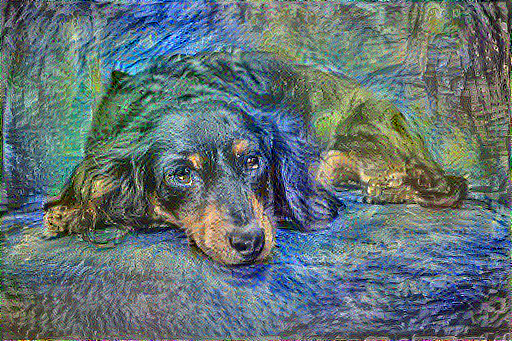

In [24]:
from IPython.display import display as ipy_display
import time

start = time.time()

epochs = 8
steps_per_epoch = 50

step = 0
for n in range(epochs):
  for m in range(steps_per_epoch):
    step += 1
    train_step(image)
    print(".", end='', flush=True)

  img = tensor_to_image(image)
  # ipy_display(img)

  # Compute current style and content losses
  outputs = extractor(image)
  style_outputs = outputs['style']
  content_outputs = outputs['content']

  style_loss = tf.add_n([
      tf.reduce_mean((style_outputs[name] - style_targets[name]) ** 2)
      for name in style_outputs.keys()
  ])
  style_loss *= style_weight / num_style_layers

  content_loss = tf.add_n([
      tf.reduce_mean((content_outputs[name] - content_targets[name]) ** 2)
      for name in content_outputs.keys()
  ])
  content_loss *= content_weight / num_content_layers

  # Print log info (will stay in the notebook output)
  print("\nTrain step: {}".format(step))
  print("Style Loss: {:.2f}, Content Loss: {:.2f}".format(style_loss.numpy(), content_loss.numpy()))

end = time.time()
print("Total time: {:.1f} seconds".format(end - start))

ipy_display(img)
